[<img src="imagens/colab-badge.png" style="width:16%; vertical-align:middle;">](https://colab.research.google.com/github/fzampirolli/pdi-vc/blob/master/notebooks_alunos/cap01/cap01_aluno.ipynb)
[<img src="imagens/github-badge.png" style="width:20%; vertical-align:middle;">](https://github.com/fzampirolli/pdi-vc)

# 1 Fundamentos e Primeiros Passos

Este capítulo inaugura a **Parte 1** do livro, dedicada aos fundamentos do Processamento Digital de Imagens (PDI). São apresentados a representação matemática de imagens digitais e os principais métodos para sua manipulação, utilizando a linguagem Python e a biblioteca `morph.py` (ZAMPIROLLI et al., 2025).

## 1.1 Objetivos

Ao final deste capítulo, você será capaz de:

- Compreender a natureza física e matemática da imagem digital $f(x,y)$.
- Identificar as faixas do espectro eletromagnético relevantes para PDI.
- Configurar o ambiente de desenvolvimento em Python.
- Realizar operações básicas: leitura, exibição e salvamento de imagens.
- Manipular estruturas de matrizes (NumPy) sem cair em armadilhas de memória.
- Acessar e modificar intensidades de pixels individualmente.
- Aplicar limiarização manual.

## 1.2 Antes de começar: *Notebooks* em Python

Este material foi construído sob o conceito de ***Literate Programming*** (Programação Literária), idealizado por Donald Knuth na década de 1980 (KNUTH, 1984). Knuth — também criador do sistema **TeX** para tipografia digital — propôs que os programas fossem escritos como uma narrativa lógica para seres humanos, intercalando código e documentação.

Para executar uma célula, pressione <kbd>Shift</kbd> + <kbd>Enter</kbd> ou clique no botão ▶️.

> ### 📝 Nota sobre o formato
>
> Nas versões renderizadas (PDF ou HTML), o código é apresentado em blocos estáticos para fins de leitura e referência. A execução interativa requer o acesso via Google Colab (disponível no topo da página) ou em ambiente local via VSCode ou Jupyter Notebook.

## 1.3 Fundamentos

O estudo de sistemas baseados em imagens compreende um ecossistema de disciplinas integradas que transformam dados visuais brutos em conhecimento estruturado. Enquanto algumas áreas focam na geração de representações, outras dedicam-se ao tratamento e à análise desses dados para dar suporte a aplicações tecnológicas complexas.

O diagrama apresentado no [Figura 1.1](#fig-01-representacao) estabelece a distinção e complementaridade entre o Processamento de Imagens (PDI) e a Visão Computacional (VC). O PDI, destacado em **verde**, tem como foco a transformação de imagem para imagem, visando melhoria de qualidade ou pré-processamento, como a remoção de ruídos e realce de contraste.

Em contrapartida, a VC, assinalada em **azul**, foca na interpretação do conteúdo visual para extrair modelos ou informações, como o reconhecimento de objetos e gestos. A região de intersecção ilustra a sinergia entre as áreas, onde o PDI prepara os dados visuais para a interpretação pela VC. O mapa também demonstra as interconexões de ambas as disciplinas com áreas como Robótica, Computação Gráfica, Inteligência Artificial e Neurociência.

<figure id="fig-01-representacao" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-01-pdf-vc.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 1.1:</strong> Diagrama relacional detalhando as distinções fundamentais, sinergias e interconexões entre Processamento de Imagens e Visão Computacional no contexto de sistemas baseados em imagens.</figcaption>
</figure>

### 1.3.1 👁️ Visão Computacional

- **Foco:** *Imagem → Modelo* (caminho inverso da Computação Gráfica).  
- **Objetivo:** Extrair informação de alto nível a partir de imagens ou vídeos.  
- **Aplicações típicas:**
  - Robótica - detecção de obstáculos, localização e navegação autônoma.
  - Vigilância e inspeção - reconhecimento de eventos, leitura de placas, controle de qualidade.
  - Sensoriamento remoto - análise de imagens de satélite, mapeamento ambiental.
  - Imagens médicas - detecção de tumores, segmentação de órgãos, auxílio ao diagnóstico.
  - Interação humano‑computador - reconhecimento de gestos, expressões faciais, rastreamento ocular.
- **Relação com outras áreas:** utiliza técnicas de Aprendizado de Máquina e IA para classificar e interpretar cenas; serve como “olhos” da Robótica.

### 1.3.2 🖼️ Processamento Digital de Imagens (PDI)

- **Foco:** *Imagem → Imagem* (geralmente - transformação de uma imagem em outra).  
- **Objetivo:** Melhorar a qualidade visual ou extrair características de baixo nível.  
- **Aplicações comuns:**
  - Eliminação de ruídos (filtros de média, mediana, gaussiano).
  - Melhoria de contraste (equalização de histograma, ajuste gamma).
  - Detecção de bordas (Sobel, Canny, Laplaciano).
  - Segmentação (limiarização, crescimento de regiões, *watershed*).
  - Transformações geométricas (redimensionamento, rotação, correção de perspectiva).
- **Relação com outras áreas:**  
  - É a **base** para a maioria dos sistemas de Visão Computacional (pré‑processamento).  
  - A Computação Gráfica frequentemente aplica PDI para pós‑processamento (ex.: suavização, realce).  
  - Técnicas de IA podem otimizar parâmetros de processamento (ex.: aprendizado de filtros).

### 1.3.3 Como as outras áreas se conectam

| Área                      | Relação com PDI e VC                                                                 |
|---------------------------|--------------------------------------------------------------------------------------|
| **Inteligência Artificial** | Fornece modelos (redes neurais, SVM) que interpretam saídas da VC.                    |
| **Robótica**              | Consome dados de VC para tomar decisões (navegação, manipulação).                     |
| **Aprendizado de Máquina**| Usa descritores extraídos pelo PDI/VC para treinar classificadores.                   |
| **Computação Gráfica**    | Caminho inverso: *modelo → imagem*; muitas vezes aplica PDI para renderização realista. |
| **Neurociência**          | Inspira modelos de PDI (ex.: filtros semelhantes a células ganglionares da retina).   |

## 1.4 Etapas do PDI

As etapas do PDI são apresentadas na [Figura 1.2](#fig-01-etapas), que podem ser compreendidas como uma cadeia de transformações que reduz a redundância dos dados em busca de significado:

*   **Baixo Nível:** Atua diretamente sobre os pixels da imagem ruidosa para realizar melhorias e filtragens, gerando como saída uma imagem limpa ou realçada.
*   **Médio Nível:** Recebe a imagem tratada e realiza a segmentação e descrição, transformando a matriz de pixels em atributos estruturados (forma, tamanho e textura).
*   **Alto Nível:** Utiliza a tabela de atributos para alimentar processos de lógica e inteligência artificial, resultando na decisão ou reconhecimento final (como o diagnóstico médico).

<figure id="fig-01-etapas" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-01-etapas.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 1.2:</strong> Representação do fluxo sequencial de processamento: a saída de cada nível torna-se a entrada do nível subsequente.</figcaption>
</figure>


A [Figura 1.3](#fig-01-etapas2) detalha a sequência completa do processamento, desde a captura até a interpretação. O fluxo inicia-se na Aquisição da Imagem (1) e prossegue com o Melhoramento (2) e a Restauração (3). Em seguida, o conteúdo é isolado pela Segmentação (4) e refinado pela Morfologia (5). A transição crucial ocorre na Representação e Descrição (6), onde objetos visuais são convertidos em dados matemáticos (área, perímetro etc.), permitindo o Reconhecimento (7). Processos auxiliares incluem o Processamento de Imagem Colorida e a Compressão, que contribuem para a eficiência do armazenamento e da análise.


<figure id="fig-01-etapas2" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-01-etapas2.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 1.3:</strong> Fluxo detalhado do PDI: da aquisição sensorial à extração de atributos e reconhecimento automatizado, incluindo em processamento colorido e compressão.</figcaption>
</figure>

## 1.5 Formação da Imagem e o Espectro

O processo de formação de uma imagem é fundamentado na interação entre a matéria e a energia radiante. Essencialmente, uma imagem é concebida quando um **sensor registra a radiação** resultante da interação com um objeto físico. No contexto da visão humana e da fotografia convencional, este fenômeno depende de uma fonte de luz que ilumine a cena; as características dos objetos são então codificadas através das **variações de intensidade e cor** da luz que atinge o sensor, conforme ilustrado na [Figura 1.4](#fig-01-luz).

<figure id="fig-01-luz" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-01-luz.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 1.4:</strong> Representação do espectro visível e sua posição em relação às demais radiações eletromagnéticas, destacando a variação dos comprimentos de onda de 380 nm a 750 nm.</figcaption>
</figure>

A **luz visível** ocupa apenas uma pequena faixa do espectro eletromagnético — entre **380 nm (violeta)** e **750 nm (vermelho)** — conforme ilustrado na [Figura 1.5](#fig-01-espectro). Sensores digitais convencionais operam nessa mesma janela, mas equipamentos especializados podem captar radiações invisíveis ao olho humano, como o infravermelho e os raios X. Em PDI, a imagem formada depende diretamente da sensibilidade espectral do sensor utilizado.

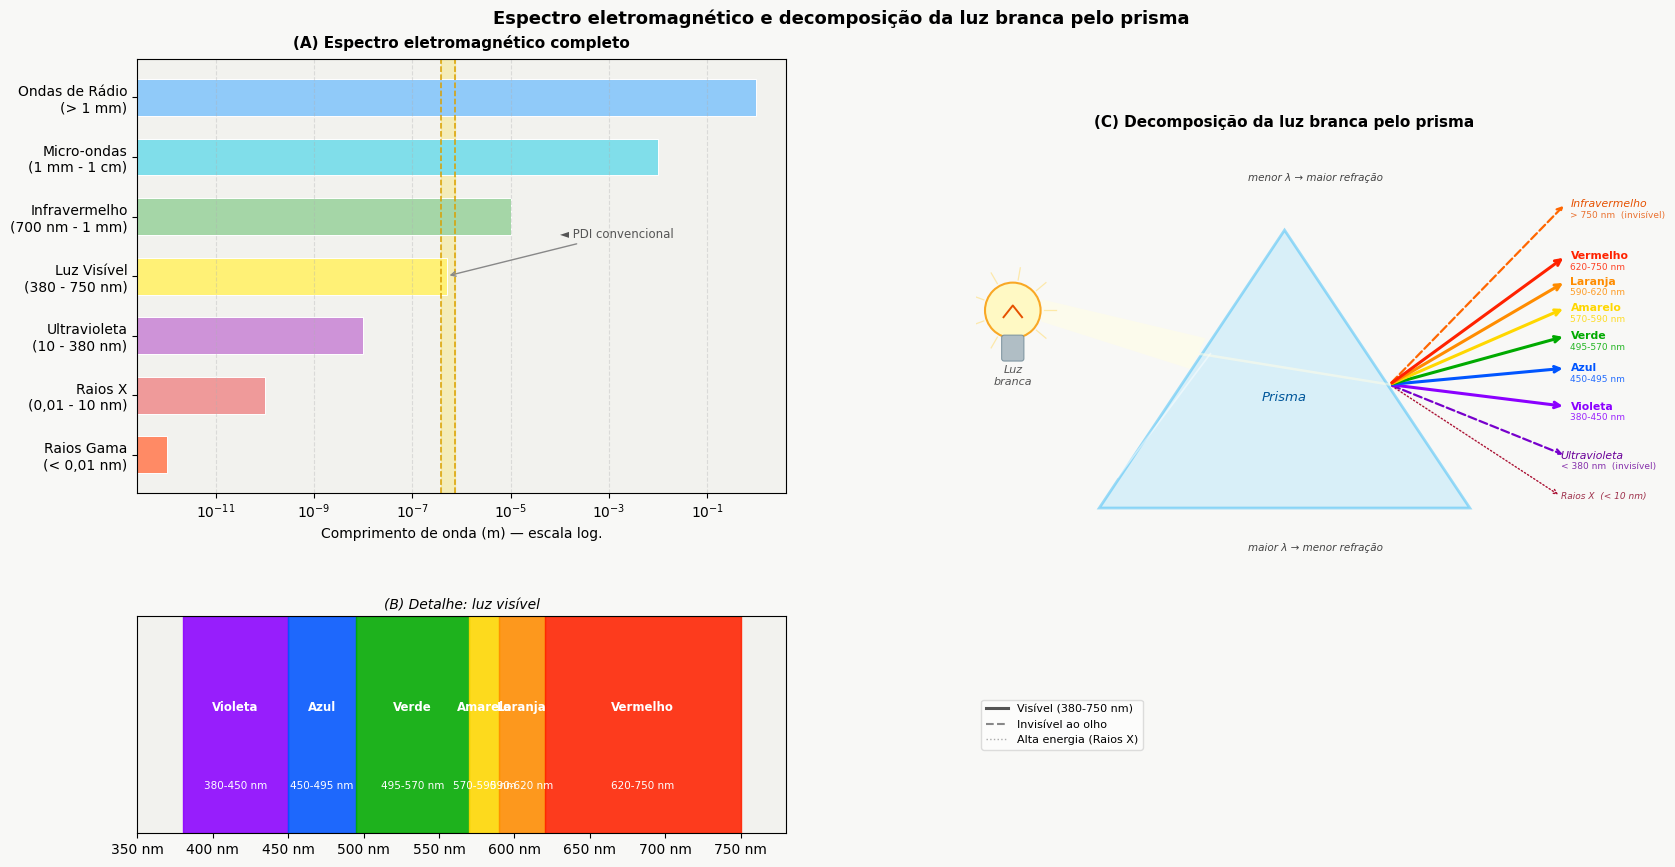

**Figura 1.5:** (A) Espectro eletromagnético completo em escala logarítmica, com destaque para a faixa visível. (B) Detalhe da luz visível (380-750 nm) e suas cores componentes. (C) Decomposição da luz branca pelo prisma: menor comprimento de onda sofre maior refração, separando UV, visível e infravermelho.


In [51]:
# @title { display-mode: "form" }
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from matplotlib.patches import Polygon

# ═══════════════════════════════════════════════════════════════════
# Dados
# ═══════════════════════════════════════════════════════════════════
faixas = [
    'Ondas de Rádio\n(> 1 mm)',
    'Micro-ondas\n(1 mm - 1 cm)',
    'Infravermelho\n(700 nm - 1 mm)',
    'Luz Visível\n(380 - 750 nm)',
    'Ultravioleta\n(10 - 380 nm)',
    'Raios X\n(0,01 - 10 nm)',
    'Raios Gama\n(< 0,01 nm)',
]
comprimentos_rep = [1e0, 1e-2, 1e-5, 5e-7, 1e-8, 1e-10, 1e-12]
cores_barras     = ['#90CAF9', '#80DEEA', '#A5D6A7', '#FFF176',
                    '#CE93D8', '#EF9A9A', '#FF8A65']

limites_nm = [380, 450, 495, 570, 590, 620, 750]
nomes_vis  = ['Violeta', 'Azul', 'Verde', 'Amarelo', 'Laranja', 'Vermelho']
cores_vis  = ['#8B00FF', '#0055FF', '#00AA00', '#FFD700', '#FF8C00', '#FF2200']
lim_vis_m  = np.array(limites_nm) * 1e-9

# ═══════════════════════════════════════════════════════════════════
# Ângulos unificados: leque proporcional do Raios X ao Infravermelho
#
#  10 posições uniformes de 50° (mais refratado) a -16° (menos refratado)
#  Índices:  0=RaiosX  1=UV  2..7=visíveis(violeta→vermelho)  9=IV
# ═══════════════════════════════════════════════════════════════════
angulos_todos = np.linspace(56, -18, 10)  # graus, mais refratado → menos

ang_xray = angulos_todos[0]   # Raios X
ang_uv   = angulos_todos[1]   # Ultravioleta
angulos_vis = angulos_todos[2:8]  # 6 cores visíveis (violeta→vermelho)
ang_iv   = angulos_todos[9]   # Infravermelho

# ═══════════════════════════════════════════════════════════════════
# Layout
# ═══════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(16, 9), facecolor='#F8F8F6')
gs = fig.add_gridspec(
    2, 2,
    width_ratios=[1.05, 1],
    height_ratios=[2.8, 1.4],
    hspace=0.38, wspace=0.30,
    left=0.06, right=0.97, top=0.93, bottom=0.07,
)
ax_spec  = fig.add_subplot(gs[0, 0])
ax_vis   = fig.add_subplot(gs[1, 0])
ax_prism = fig.add_subplot(gs[:, 1])

for ax in (ax_spec, ax_vis, ax_prism):
    ax.set_facecolor('#F2F2EE')

# ═══════════════════════════════════════════════════════════════════
# Painel A - Espectro completo
# ═══════════════════════════════════════════════════════════════════
ax_spec.barh(faixas, comprimentos_rep,
             color=cores_barras, edgecolor='white', linewidth=0.7, height=0.62)
ax_spec.set_xscale('log')
ax_spec.set_xlabel('Comprimento de onda (m) — escala log.', fontsize=10)
ax_spec.set_title('(A) Espectro eletromagnético completo',
                  fontsize=11, fontweight='bold', pad=8)
ax_spec.invert_yaxis()
ax_spec.grid(axis='x', which='both', linestyle='--', alpha=0.35)
ax_spec.axvspan(380e-9, 750e-9, color='#FFD700', alpha=0.22, zorder=0)
ax_spec.axvline(380e-9, color='#DAA000', lw=1.1, ls='--', zorder=1)
ax_spec.axvline(750e-9, color='#DAA000', lw=1.1, ls='--', zorder=1)
idx_vis = faixas.index('Luz Visível\n(380 - 750 nm)')
ax_spec.annotate(
    '◄ PDI convencional',
    xy=(5e-7, idx_vis), xytext=(1e-4, idx_vis - 0.65),
    fontsize=8.5, color='#555',
    arrowprops=dict(arrowstyle='->', color='#888', lw=1.0),
)

# ═══════════════════════════════════════════════════════════════════
# Painel B - Detalhe da luz visível
# ═══════════════════════════════════════════════════════════════════
ax_vis.set_xlim(350e-9, 780e-9)
ax_vis.set_ylim(0, 1)
for i, nome in enumerate(nomes_vis):
    xi, xf = lim_vis_m[i], lim_vis_m[i + 1]
    cx = (xi + xf) / 2
    ax_vis.axvspan(xi, xf, color=cores_vis[i], alpha=0.88)
    ax_vis.text(cx, 0.58, nome,
                ha='center', va='center', fontsize=8.5,
                fontweight='bold', color='white')
    ax_vis.text(cx, 0.22, f'{limites_nm[i]}-{limites_nm[i+1]} nm',
                ha='center', va='center', fontsize=7.5, color='white')
ax_vis.set_yticks([])
ax_vis.set_title('(B) Detalhe: luz visível',
                 fontsize=10, style='italic', pad=5)
ax_vis.xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{x*1e9:.0f} nm')
)

# ═══════════════════════════════════════════════════════════════════
# Painel C - Prisma
# ═══════════════════════════════════════════════════════════════════
ax_prism.set_xlim(0, 10)
ax_prism.set_ylim(0, 10)
ax_prism.set_aspect('equal')
ax_prism.axis('off')
ax_prism.set_title('(C) Decomposição da luz branca pelo prisma',
                   fontsize=11, fontweight='bold', pad=8)

# Vértices do prisma
px_esq, py_esq = 2.0, 4.0
px_dir, py_dir = 8.0, 4.0
px_top, py_top = 5.0, 8.5

prism_pts = np.array([[px_esq, py_esq], [px_dir, py_dir], [px_top, py_top]])
ax_prism.add_patch(Polygon(prism_pts, closed=True,
                            fc='#B3E5FC', ec='#29B6F6', lw=2.0,
                            alpha=0.45, zorder=5))
ax_prism.plot([2.3, 3.8], [4.5, 6.5], color='white', lw=1.2, alpha=0.5, zorder=6)
ax_prism.text(5.0, 5.8, 'Prisma',
              ha='center', va='center', fontsize=9.5,
              color='#01579B', style='italic', zorder=7)

# ── Lâmpada ──────────────────────────────────────────────────────
lx, ly = 0.6, 7.2
ax_prism.add_patch(plt.Circle((lx, ly), 0.45,
                               color='#FFF9C4', ec='#F9A825', lw=1.5, zorder=8))
ax_prism.plot([lx - 0.15, lx, lx + 0.15],
              [ly - 0.11, ly + 0.08, ly - 0.11],
              color='#E65100', lw=1.4, zorder=9)
for ang in np.linspace(0, 360, 9, endpoint=False):
    r0, r1 = 0.50, 0.70
    ax_prism.plot(
        [np.cos(np.radians(ang)) * r0 + lx,
         np.cos(np.radians(ang)) * r1 + lx],
        [np.sin(np.radians(ang)) * r0 + ly,
         np.sin(np.radians(ang)) * r1 + ly],
        color='#FFE082', lw=0.9, alpha=0.65, zorder=7,
    )
ax_prism.add_patch(mpatches.FancyBboxPatch(
    (lx - 0.14, ly - 0.78), 0.28, 0.34,
    boxstyle='round,pad=0.04', fc='#B0BEC5', ec='#78909C', lw=0.7, zorder=8,
))
ax_prism.text(lx, ly - 1.2, 'Luz\nbranca',
              ha='center', fontsize=8, color='#555', style='italic')

# ── Feixe branco → prisma ────────────────────────────────────────
inc_x, inc_y = 3.6, 6.5
beam = np.array([
    [lx + 0.46, ly + 0.18],
    [lx + 0.46, ly - 0.18],
    [inc_x - 0.12, inc_y - 0.25],
    [inc_x + 0.12, inc_y + 0.25],
])
ax_prism.add_patch(Polygon(beam, closed=True,
                            fc='#FFFDE7', ec='none', alpha=0.65, zorder=4))

# Ponto de saída (face direita do prisma)
out_x, out_y = 6.7, 6.0
ax_prism.plot([inc_x, out_x], [inc_y, out_y],
              color='#FFFDE7', lw=1.8, alpha=0.55, zorder=6)

# ── Função auxiliar: calcula yf a partir de ângulo ───────────────
def yf_at(x_dest, ang_deg):
    dx = x_dest - out_x
    return out_y - dx * np.tan(np.radians(ang_deg)) + 2

# ── Raios visíveis ───────────────────────────────────────────────
x_fim = 9.55
for i, (nome, cor, ang) in enumerate(zip(nomes_vis, cores_vis, angulos_vis)):
    yf = yf_at(x_fim, ang)
    ax_prism.annotate(
        '', xy=(x_fim, yf), xytext=(out_x, out_y),
        arrowprops=dict(arrowstyle='->', color=cor, lw=2.2, mutation_scale=10),
        zorder=4,
    )
    ax_prism.text(x_fim + 0.08, yf,
                  nome, va='center', fontsize=7.8, color=cor, fontweight='bold')
    ax_prism.text(x_fim + 0.08, yf - 0.18,
                  f'{limites_nm[i]}-{limites_nm[i+1]} nm',
                  va='center', fontsize=6.5, color=cor, alpha=0.85)

# ── Ultravioleta ─────────────────────────────────────────────────
yf_uv = yf_at(x_fim, ang_uv) -0.01
ax_prism.annotate(
    '', xy=(x_fim, yf_uv), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#7700CC',
                    lw=1.6, linestyle='dashed', mutation_scale=9),
    zorder=3,
)
ax_prism.text(x_fim -0.08 , yf_uv,
              'Ultravioleta', va='center', fontsize=7.8,
              color='#6A0099', style='italic')
ax_prism.text(x_fim -0.08 , yf_uv - 0.18,
              '< 380 nm  (invisível)', va='center',
              fontsize=6.5, color='#6A0099', alpha=0.8)

# ── Raios X ──────────────────────────────────────────────────────
yf_xr = yf_at(x_fim - 0.08, ang_xray) +0.3
ax_prism.annotate(
    '', xy=(x_fim - 0.08, yf_xr), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#AA1133',
                    lw=1.0, linestyle='dotted', mutation_scale=8),
    zorder=2,
)
ax_prism.text(x_fim - 0.08, yf_xr,
              'Raios X  (< 10 nm)', va='center',
              fontsize=6.5, color='#880022', style='italic', alpha=0.8)

# ── Infravermelho ─────────────────────────────────────────────────
yf_iv = yf_at(x_fim, ang_iv)
ax_prism.annotate(
    '', xy=(x_fim, yf_iv), xytext=(out_x, out_y),
    arrowprops=dict(arrowstyle='->', color='#FF6600',
                    lw=1.6, linestyle='dashed', mutation_scale=9),
    zorder=3,
)
ax_prism.text(x_fim + 0.08, yf_iv,
              'Infravermelho', va='center', fontsize=7.8,
              color='#E65100', style='italic')
ax_prism.text(x_fim + 0.08, yf_iv - 0.18,
              '> 750 nm  (invisível)', va='center',
              fontsize=6.5, color='#E65100', alpha=0.8)

# ── Anotações de refração ─────────────────────────────────────────
ax_prism.text(5.5, 9.3, 'menor λ → maior refração',
              ha='center', fontsize=7.5, color='#444', style='italic')
ax_prism.text(5.5, 3.3, 'maior λ → menor refração',
              ha='center', fontsize=7.5, color='#444', style='italic')

# ── Legenda ──────────────────────────────────────────────────────
ax_prism.plot([], [], color='#555', lw=2.2,          label='Visível (380-750 nm)')
ax_prism.plot([], [], color='#888', lw=1.5, ls='--', label='Invisível ao olho')
ax_prism.plot([], [], color='#AAA', lw=1.0, ls=':',  label='Alta energia (Raios X)')
ax_prism.legend(loc='lower left', fontsize=8,
                framealpha=0.65, edgecolor='#CCCCCC')

# ═══════════════════════════════════════════════════════════════════
plt.suptitle(
    'Espectro eletromagnético e decomposição da luz branca pelo prisma',
    fontsize=13, fontweight='bold', y=0.985,
)
plt.show()

## 1.6 O que é uma Imagem Digital?

Uma **imagem digital** é formada por uma grade de **pixels** (*Picture Elements*), onde cada pixel é a menor unidade elementar da imagem.

> ### 💡 1.6.1 O que é um Pixel?
>
> Um **pixel** é a menor unidade endereçável que compõe uma imagem digital. Cada pixel ocupa uma posição única na grade e armazena um ou mais valores numéricos que representam sua intensidade ou cor.

### Representação Matemática

Diferente de uma função contínua, o domínio de uma imagem digital é um plano retangular finito $\mathbb{E} \subset \mathbb{Z}^2$, que representa a grade de amostragem. Este domínio é indexado por coordenadas inteiras:

<a id="eq-01-dominio"></a>
$$
\mathbb{E}  = \{ (x, y) \in \mathbb{Z}^2 \mid 0 \le x < L,\; 0 \le y < H \} \tag{1.1}
$$


Onde:

*   **$L$**: representa a largura da imagem (número de colunas).
*   **$H$**: representa a altura da imagem (número de linhas).

A imagem digital é uma função que associa cada par de coordenadas $(x,y)$ a um ou mais valores que descrevem a aparência do pixel. 

<a id="eq-01-image"></a>
$$
f: \mathbb{E}  \to \mathcal{V} \tag{1.2}
$$


O conjunto $\mathcal{V}$ define os valores possíveis para o pixel (codomínio), variando conforme o tipo de imagem, como demonstrado na [Tabela 1.1](#tbl-01-tipos-imagem).

<a id="tbl-01-tipos-imagem"></a>

**Tabela 1.1:** Principais tipos de imagem digital e seus respectivos conjuntos de valores possíveis para cada pixel.

| Tipo de imagem | $\mathcal{V}$ (valores do pixel) | Representação |
|:---|:---|:---:|
| **Binária** | $\{0, 1\}$ ou $\{0, 255\}$ | ⬛◻️ |
| **Tons de cinza** | $\{0, 1, \dots, 255\}$ | ░▒▓█ |
| **Colorida (RGB)** | $\{0, \dots, 255\}^3$ (triplas ordenadas de valores) | 🟥🟩🟦 |


**Exemplo prático:** Uma imagem colorida (RGB) é representada matematicamente por uma função que retorna três valores para cada pixel. No computador, isso resulta em três matrizes sobrepostas (canais R, G e B), onde cada célula contém um valor de intensidade para aquele canal específico no pixel.

## 1.7 Configuração do Ambiente

Este material fundamenta-se no ecossistema científico do Python, com destaque para o **NumPy** (matemática matricial), **OpenCV** (visão computacional padrão de mercado) e a biblioteca **morph.py** (ZAMPIROLLI et al., 2025), desenvolvida especificamente para fins didáticos neste livro.

Atualmente, o projeto disponibiliza a versão em **Python** e **Português**. A arquitetura do sistema, no entanto, foi projetada para expansão futura, permitindo a adaptação automatizada para outras linguagens de programação (como C++ e Java) e idiomas, por meio de APIs de tradução.

Os **Exercícios de Programação (EPs)** do final de cada capítulo integram o módulo `testsuite.py`, já disponível para práticas em Python, C, C++, Java, JavaScript e R, garantindo a validação imediata das soluções propostas nos notebooks de estudo.

### 1.7.1 📦 Bibliotecas Utilizadas

| Biblioteca | Função principal |
|:-----------|:-----------------|
| `numpy` | Representação matricial de imagens |
| `opencv-python` | Leitura, escrita e operações de visão computacional |
| `matplotlib` | Visualização de imagens e gráficos |
| `morph.py` | Abstração didática das operações de PDI |

> ### 📝 1.8 Versões do `morph.py`
>
> A biblioteca `morph.py` possui duas versões públicas:
>
> - **Versão 1.0** — versão original, publicada junto ao artigo apresentado no EduComp 2024:
>   <https://github.com/fzampirolli/morph>
>
> - **Versão 1.1** — versão compacta, utilizada nas atividades deste livro:
>   <https://github.com/fzampirolli/pdi-vc/blob/master/morph/morph.py>
>
> A versão 1.1 foi necessária para uso nas atividades do **Moodle/VPL** (Laboratório Virtual de Programação). Na versão 1.0, bibliotecas como `matplotlib`, `requests` e `skimage` eram carregadas no momento do `import morph`, causando erro de memória (`Jail: out of memory, 128MiB`) no ambiente restrito do VPL.
>
> Na versão 1.1, esses imports foram convertidos para **carregamento lazy**: cada biblioteca é importada apenas dentro do método que a utiliza, e somente quando esse método é de fato chamado. Assim, um simples `import morph` carrega apenas `numpy` e `cv2`, que são suficientes para a maioria dos EPs.

In [52]:
import os, importlib, urllib.request, numpy as np, matplotlib.pyplot as plt

# URLs do repositório
BASE_URL = "https://raw.githubusercontent.com/fzampirolli/pdi-vc/master/morph"
for f in ["morph.py"]:
    if not os.path.exists(f):
        urllib.request.urlretrieve(f"{BASE_URL}/{f}", f)

import morph
importlib.reload(morph)
from morph import mm

# Correção: Verifica se o atributo existe antes de imprimir, 
# ou simplesmente confirma o carregamento do módulo.
version = getattr(morph, "__version__", "local_file")
print(f"✅ Ambiente pronto. Módulo 'morph' carregado com sucesso.")
print(f"📦 Funções disponíveis no mm: \n{dir(mm)[-5:]}...") 

✅ Ambiente pronto. Módulo 'morph' carregado com sucesso.
📦 Funções disponíveis no mm: 
['verifyBoundBox', 'watershed', 'watershed0', 'watershedB', 'write']...


## 1.9 Fundamentos de Matrizes - atenção à cópia de referências

Como uma imagem digital é uma matriz, precisamos saber criá-las corretamente. Em Python, existe uma armadilha comum ao usar o operador * em listas:

> ### ⚠️ Atenção à cópia de referências
>
> Ao fazer `m = [[0]*2]*3`, você não cria 3 linhas independentes, mas sim 3 referências para a **mesma** linha. Alterar um valor em uma linha alterará todas as outras!

Para visualizar esse comportamento, você pode testar o código no [Python Tutor](https://pythontutor.com/) e comparar com a forma correta de criar matriz com listas: `m = [[0]*2 for _ in range(3)]`.

A forma recomendada e padrão em Processamento Digital de Imagens é usar **NumPy**, que cria matrizes com dados independentes e oferece eficiência computacional. O código a seguir mostra diferentes formas de criação de imagens sintéticas — o resultado é exibido na [Figura 1.6](#fig-imagens-sinteticas).


Matriz Aleatória Gerada:
226 156  71 174 248  40 
121 173  36 183  57 156 
 44  65 200 214 178  93 
250 139  31 165 105 155 



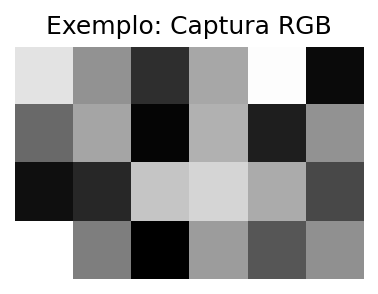

**Figura 1.6:** Exemplo de imagem sintética gerada por matriz aleatória 4x6.


In [53]:
# Criando uma imagem preta (zeros) de 5x5 pixels
img_preta = np.zeros((5, 5), dtype='uint8')

# Criando uma imagem branca (255) de 5x5 pixels
img_branca = np.ones((5, 5), dtype='uint8') * 255

# Criando uma imagem aleatória para testes (Ruído)
img_random = mm.randomImage(4, 6, maxValue=255)

print("Matriz Aleatória Gerada:")
print(mm.drawImage(img_random))

mm.show(img_random, title="Exemplo: Captura RGB")  # menor

## 1.10 Lendo e Exibindo Imagens

Em Python, as imagens são lidas como *arrays* do NumPy. Isso significa que toda a potência da álgebra linear está disponível para o processamento de imagens.

A operação mais básica em PDI é a leitura de uma imagem.
A função `mm.read()` da `morph.py` aceita caminhos locais e URLs, ver o resultado na [Figura 1.7](#fig-01-natureza).

Dimensões (H, W, Canais): (1365, 2048, 3)
Tipo de dado: uint8


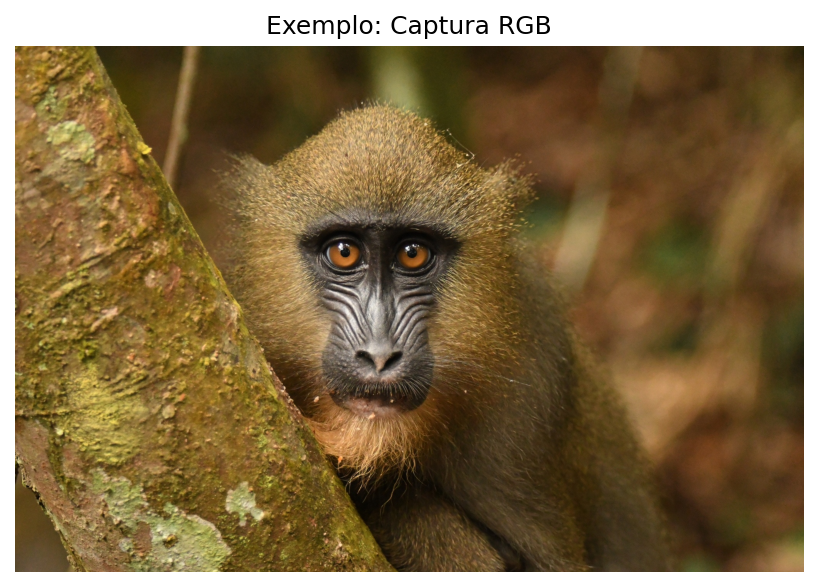

**Figura 1.7:** Mandrill (Mandrillus sphinx) in Gabon GPS: (-1.93867, 13.09674). Crédito: Julien Renoult (CC BY 4.0).


In [54]:
import os
import numpy as np

url     = "https://upload.wikimedia.org/wikipedia/commons/8/87/Mandrillus_sphinx_339428057.jpg"
caminho = "imagens/mandrill.jpg"

if not os.path.exists(caminho):
    os.makedirs("imagens", exist_ok=True)
    img_obj = mm.read(url, pil=True)
    mm.write(img_obj, caminho)
else:
    img_obj = mm.read(caminho, pil=True)

img = np.array(img_obj)

print(f"Dimensões (H, W, Canais): {img.shape}")
print(f"Tipo de dado: {img.dtype}")

mm.show(img, title="Exemplo: Captura RGB")

### Alternativa: Baixando a imagem localmente

Se por algum motivo a leitura direta da URL não funcionar (firewall, restrições de rede, ou se você preferir trabalhar com arquivos locais), uma abordagem simples é **baixar a imagem** usando o comando `wget` (disponível em ambientes Linux, macOS e no Google Colab) e depois carregá-la com `mm.read()` a partir do arquivo salvo.

```bash
!wget -O mandrill.png https://upload.wikimedia.org/wikipedia/commons/8/87/Mandrillus_sphinx_339428057.jpg
```

```python
img = mm.read('mandrill.png')
mm.show(img, title="Exemplo: Captura RGB (arquivo local)")
```

#### Explicação:
- `!wget -O mandrill.png <URL>` baixa a imagem da Wikimedia e a salva com o nome `mandrill.png`.
- `mm.read('mandrill.png')` lê o arquivo local (sem necessidade de cabeçalhos HTTP ou tratamento especial).
- Essa estratégia é útil quando você quer **evitar dependências de rede** durante a execução ou **reutilizar a mesma imagem** várias vezes sem novo download.


> ### 💡 Nota
>
> O prefixo `!` funciona no Jupyter Notebook, JupyterLab e Google Colab. Em um terminal comum, basta remover o `!`. Se o `wget` não estiver instalado, instale-o com `apt install wget` (Linux) ou use `curl -o mandrill.png <URL>` como alternativa.

## 1.11 Conversão de Tipos e Limiarização

Conforme vimos, uma imagem colorida no espaço RGB é representada pela função:

<a id="eq-01-cinza"></a>
$$
f: \mathbb{E} \to \{0,1,\dots,255\}^3
$$

Ou seja, para cada pixel $(x,y)$, temos três valores $(R,G,B)$ que definem sua cor.

### Conversão para Tons de Cinza

Para converter uma imagem RGB em tons de cinza (*grayscale*), é necessário combinar os três canais em um único valor de intensidade $g$, que representa o brilho percebido. Como o olho humano não é igualmente sensível ao vermelho, verde e azul, utiliza-se uma **média ponderada**. O padrão [ITU-R BT.601](https://www.itu.int/rec/R-REC-BT.601/) ({ITU-R}, 2011) define os seguintes pesos:

$$
g = 0.299\,R + 0.587\,G + 0.114\,B \tag{1.3}
$$


Após o cálculo, o valor $g$ é arredondado para o inteiro mais próximo e ajustado ao intervalo $[0, 255]$. O resultado é uma nova imagem, agora em tons de cinza, representada por:

<a id="eq-01-limiar"></a>
$$
f_{\text{cinza}}: \mathbb{E} \to \{0,1,\dots,255\}
$$

### Limiarização (*Thresholding*)

A partir da imagem em tons de cinza $f_{\text{cinza}}(x,y)$, uma operação fundamental é a **limiarização**, que produz uma imagem **binária** (apenas preto e branco). Para isso, escolhe-se um valor de corte $T$ (geralmente no intervalo $[0,255]$) e define-se:

$$
f_{\text{bin}}(x,y) = 
\begin{cases} 
255 & \text{se } f_{\text{cinza}}(x,y) > T \\[4pt]
0 & \text{caso contrário}
\end{cases} \tag{1.4}
$$


**Exemplo:** Com $T = 128$, pixels com intensidade acima de 128 tornam-se brancos (255); os demais tornam-se pretos (0).

A limiarização é amplamente usada para **segmentar objetos do fundo**, extrair bordas ou criar máscaras binárias para processamento posterior. 

> **Nota:** O valor 255 representa o branco máximo em imagens de 8 bits, enquanto 0 representa o preto absoluto.

### Exemplo prático de conversão e limiarização

A [Figura 1.8](#fig-01-processamento-basico) ilustra os principais passos para transformar uma imagem colorida em tons de cinza e, em seguida, convertê-la em uma imagem binária por limiarização. 
O código a seguir implementa essas etapas:

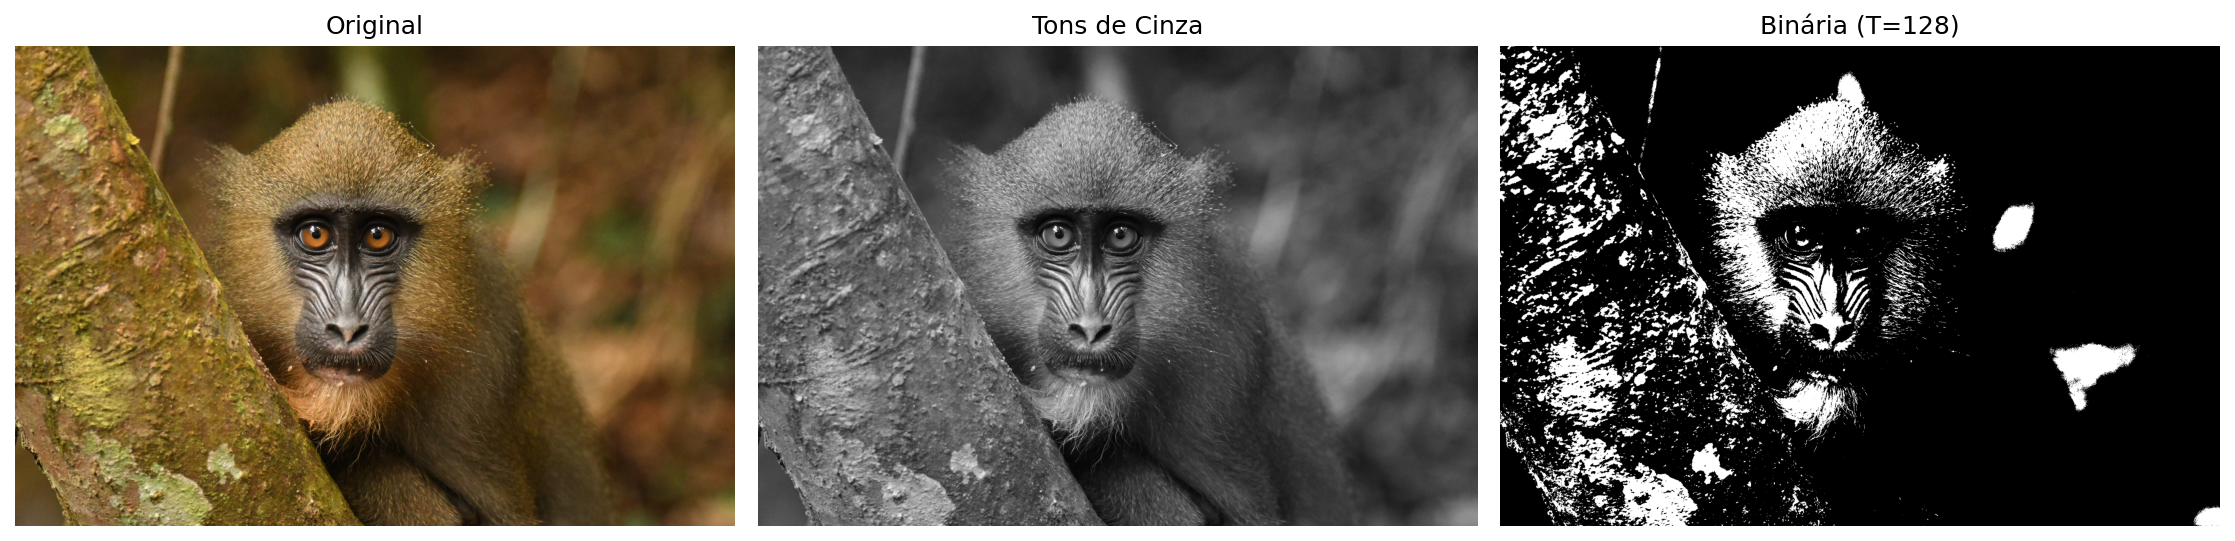

**Figura 1.8:** Processamento básico de imagens: (a) imagem original, (b) imagem em tons de cinza, (c) imagem binarizada por limiar (T=128).


In [55]:
import matplotlib.pyplot as plt

# 1. Converter para Tons de Cinza
img_gray = mm.gray(img)

# 2. Aplicar limiar (Pixels > 128 tornam-se 255, outros 0)
limiar = 128
img_binaria = mm.threshold(img_gray, limiar)

# Uso da nova função
mm.show(
    [img, img_gray, img_binaria], 
    titles=["Original", "Tons de Cinza", f"Binária (T={limiar})"],
    cols=3
)

## 1.12 Limiarização pelo método de Otsu

Conforme apresentado na [Equação 1.4](#eq-01-limiar), a limiarização converte uma imagem em tons de cinza para binária usando um valor de corte $T$. Até agora fixamos $T = 128$ manualmente.

```python
img_bin_fixo = mm.threshold(img_gray, T=128)
```

Entretanto, a escolha manual de $T$ nem sempre é trivial. A biblioteca `mm` oferece uma alternativa automática: quando o parâmetro `limiar` **não é fornecido**, a função `mm.threshold(img_gray)` calcula o valor de $T$ pelo **método de Otsu** (LOTUFO et al., 1997). Esse método, que será detalhado em capítulos futuros, maximiza a variância entre classes do histograma, separando automaticamente os pixels de objeto e fundo.

O código abaixo compara a limiarização manual ($T=128$) com a automática (Otsu), mostrando também o valor de $T$ calculado:

Limiar calculado por Otsu: T = 96.0


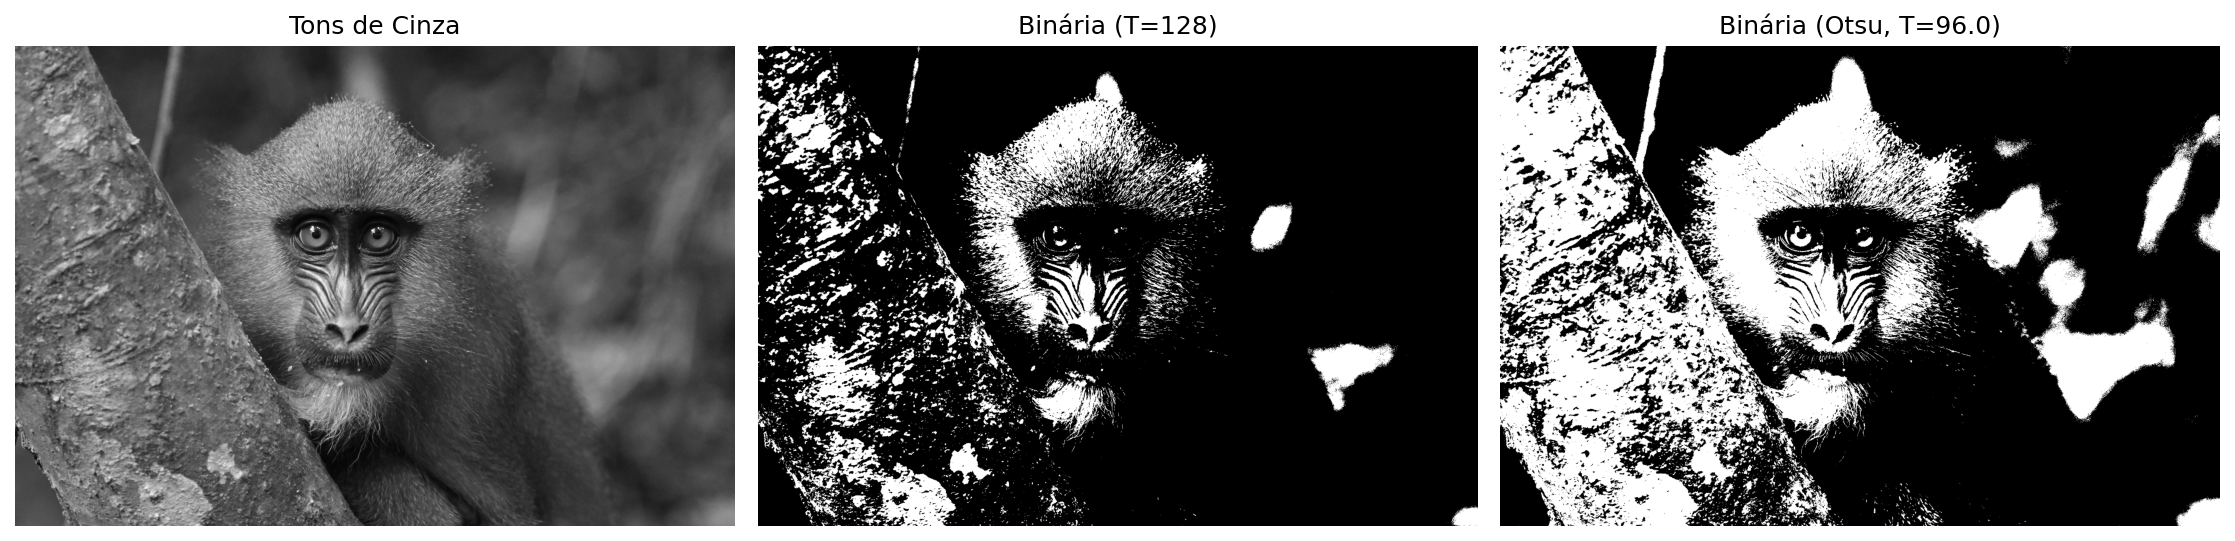

**Figura 1.9:** Comparação entre limiarização manual (T=128) e automática (Otsu) sobre a imagem em tons de cinza.


In [56]:
import cv2
# Limiarização com T fixo (manual)
T_fixo = 128
img_bin_fixo = mm.threshold(img_gray, T_fixo)

# Limiarização pelo método de Otsu (T automático)
T_otsu, img_bin_otsu = cv2.threshold(img_gray, 0, 255,
                                      cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Limiar calculado por Otsu: T = {T_otsu}')
# ou simplesmente:
# img_bin_otsu = mm.threshold(img_gray)

# Exibição lado a lado
mm.show(
    [img_gray, img_bin_fixo, img_bin_otsu], 
    titles=["Tons de Cinza", f"Binária (T={T_fixo})", f"Binária (Otsu, T={T_otsu})"],
    cols=3
)

A [Figura 1.9](#fig-01-otsu) mostra que o limiar obtido por Otsu se adapta automaticamente à imagem, resultando em uma binarização mais eficiente do que um valor fixo, especialmente quando as intensidades do objeto e do fundo são bem separadas no histograma. Essa técnica é amplamente utilizada em sistemas de visão computacional para binarização de documentos, detecção de objetos e pré‑processamento de imagens.

> ### 💡 Simplicidade da biblioteca `morph.py`
>
> Enquanto o OpenCV exige a chamada completa:
>
> ```python
> T_otsu, img_bin = cv2.threshold(img_gray, 0, 255,
>                                 cv2.THRESH_BINARY + cv2.THRESH_OTSU)
> ```
>
> a biblioteca `mm` abstrai toda essa complexidade: basta chamar `mm.threshold(img_gray)`. O limiar de Otsu é calculado automaticamente e a imagem binária é retornada diretamente. Essa abordagem permite concentrar-se no conceito, não nos detalhes de implementação.

## 1.13 Acesso a Pixels

Em Python com NumPy, uma imagem é representada como um **array multidimensional**. Para acessar um pixel específico, utilizam-se as coordenadas **linha** (eixo Y) e **coluna** (eixo X): `img[linha, coluna]`.  

O código abaixo demonstra como obter o valor de um pixel em uma imagem RGB e em sua versão em tons de cinza, além de criar uma pequena imagem sintética para visualizar a estrutura de uma matriz de pixels.

Pixel na posição (100,100):
  - Tons de cinza : 64
  - RGB           : R=77, G=66, B=20

Matriz da imagem sintética 5×5:
[[  0   0   0   0   0]
 [  0   0   0   0   0]
 [  0   0 255   0   0]
 [  0   0   0   0   0]
 [  0   0   0   0   0]]


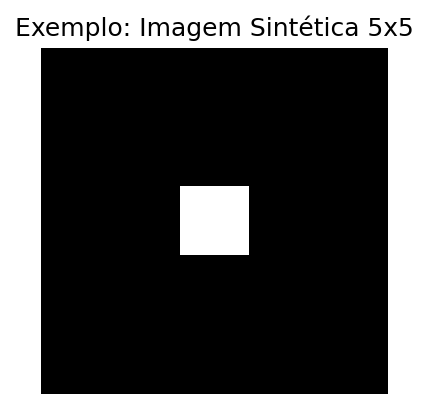

**Figura 1.10:** Exemplo de matriz sintética 5×5 com pixel central branco.


In [57]:
import numpy as np
import matplotlib.pyplot as plt

# Coordenadas do pixel que queremos examinar
r, c = 100, 100

# Acessa o pixel na imagem em tons de cinza (um valor escalar)
pixel_cinza = img_gray[r, c]

# Acessa o pixel na imagem colorida RGB (vetor de 3 valores)
pixel_rgb = img[r, c]

print(f'Pixel na posição ({r},{c}):')
print(f'  - Tons de cinza : {pixel_cinza}')
print(f'  - RGB           : R={pixel_rgb[0]}, G={pixel_rgb[1]}, B={pixel_rgb[2]}')

# Cria uma imagem sintética 5×5 com todos os pixels pretos (0)
syn = np.zeros((5, 5), dtype=np.uint8)
# Torna o pixel central (linha 2, coluna 2) branco (255)
syn[2, 2] = 255

print("\nMatriz da imagem sintética 5×5:")
print(syn)

# Exibe a imagem sintética
# plt.figure(figsize=(3, 3))
# plt.imshow(syn, cmap='gray', vmin=0, vmax=255)
# plt.title("Imagem sintética 5×5\n(pixel central branco)")
# plt.axis('off')
# plt.tight_layout()
# plt.show()
# ou simplesmente:

mm.show(syn, title="Exemplo: Imagem Sintética 5x5")



**Explicação linha a linha:**

1. `img_gray[r, c]` - retorna um único número inteiro entre 0 e 255, correspondente ao nível de cinza naquela posição.  
2. `img[r, c]` - retorna uma tupla ou array com três valores (R, G, B).  
3. `np.zeros((5,5), dtype=np.uint8)` - cria uma matriz $5\times 5$ preenchida com zeros (preto).  
4. `syn[2, 2] = 255` - altera o elemento central da matriz para 255 (branco), demonstrando como modificar um pixel.  
5. A exibição com `plt.imshow` revela um pequeno quadrado com um ponto branco no meio, ilustrando visualmente a estrutura discreta da imagem.

A [Figura 1.10](#fig-01-pixel-acesso) mostra os valores impressos e a imagem sintética. A indexação em Python é *zero‑based*; portanto, o canto superior esquerdo corresponde a `(0,0)`. A ordem **linha × coluna** corresponde à estrutura matricial da imagem: primeira dimensão → altura (Y), segunda dimensão → largura (X).

## 1.14 Resumo

Neste capítulo, apresentaram-se os fundamentos de representação de imagens digitais: a definição de pixel, a estruturação de imagens em matrizes e o impacto da amostragem e da quantização na qualidade final:

- **Imagem digital** = função $f(x,y)$ que mapeia coordenadas para intensidades (escalares ou vetoriais).
- **Domínio**: conjunto finito $\mathbb{E} = \{(x,y) \in \mathbb{Z}^2 \mid 0 \le x < L,\; 0 \le y < H\}$.
- **Tipos principais**: binária ($\mathcal{V} = \{0, 255\}$), tons de cinza ($\mathcal{V} = [0,255]$) e RGB ($\mathcal{V} = [0,255]^3$).
- A biblioteca `morph.py` (ou `mm`) oferece funções didáticas para operações básicas de PDI, como `mm.gray()`, `mm.threshold()`, `mm.show_multiple()`.
- **Armadilha NumPy**: nunca use `[[0]*n]*m` para criar matrizes — use sempre `np.zeros()` ou `np.ones()`.
- **Limiarização** converte tons de cinza em binária; o **método de Otsu** determina o valor de corte automaticamente maximizando a variância entre classes.
- Acesso a pixels via `img[linha, coluna]`, com indexação **zero-based**.

O Capítulo 2 abordará **histogramas e equalização de contraste**.

## 1.15 🤖 Uso do NotebookLM como Tutor Complementar

Nesta edição, além dos notebooks interativos no Google Colab, incentivamos o uso do **NotebookLM** como ferramenta complementar de aprendizagem. Essa ferramenta de IA utiliza exclusivamente os documentos fornecidos pelo autor como base de conhecimento, garantindo respostas coerentes com o conteúdo do livro.

Para cada capítulo, preparamos um projeto específico na plataforma. Para uma experiência de estudo ampliada, utilize o acesso abaixo:

> ### ❗ 🎓 Estude com o Tutor Inteligente
>
> Para interagir com o conteúdo deste capítulo, acesse o link a seguir. O ambiente contém materiais didáticos em diferentes formatos, gerados a partir do **PDF** do capítulo. Na plataforma, explore especialmente as opções **Guia de Estudo** e **Conversa** para aprofundar sua compreensão.
>
> [🚀 ACESSAR NOTEBOOKLM: CAPÍTULO 01](https://notebooklm.google.com/notebook/022d09fb-4dee-46b1-ad18-787987fe976d)

### Funcionalidades Disponíveis na Plataforma

O **NotebookLM** oferece uma suíte avançada de ferramentas baseadas em IA para transformar o conteúdo estático do livro em uma experiência de aprendizado dinâmica e multimídia. Conforme ilustrado na [Figura 1.11](#fig-01-notebooklm), a plataforma utiliza técnicas de **RAG** (*Retrieval-Augmented Generation*), fundamentadas no trabalho de Lewis et al. (2020), para basear as respostas estritamente nos documentos fornecidos e minimizar a ocorrência de alucinações.

As principais funcionalidades incluem:

* **Resumos Multimodais (Áudio e Vídeo)**: Geração de conversas naturais entre especialistas no formato de **Resumo em Áudio** (estilo *podcast*) e **Resumo em Vídeo**, discutindo os temas centrais do capítulo, como as diferenças entre processamento de imagens e visão computacional, ou a interpretação de transformações como a limiarização e o método de Otsu.
* **Visualização de Estruturas (Mapa Mental e Infográfico)**: Criação automática de diagramas que conectam visualmente os conceitos, por exemplo, o fluxo de processamento desde a captura da imagem digital, passando pela conversão para tons de cinza, limiarização e segmentação binária.
* **Ferramentas de Avaliação (Teste e Cartões Didáticos)**: Geração de **Testes** de múltipla escolha e **Cartões Didáticos** (*flashcards*) para fixação de conhecimento, baseados no texto autoral (ex.: perguntas sobre a fórmula de conversão RGB→cinza ou sobre o funcionamento do limiar global e de Otsu).
* **Apoio à Apresentação (*Slides* e Relatórios)**: Auxílio na estruturação de **Apresentações de *Slides*** e na redação de **Relatórios** técnicos e ***Briefings***, facilitando a comunicação de resultados de experimentos com imagens.
* **Análise de Dados (Tabela de Dados)**: Organização de dados extraídos do texto em tabelas estruturadas, auxiliando na compreensão de exemplos práticos, como a comparação entre diferentes valores de limiar.
* ***Chat* Contextualizado**: Permite o questionamento direto sobre o código e a teoria, como: *"Como implementar a conversão de RGB para tons de cinza usando os pesos do padrão ITU‑R BT.601?"* ou *"O que acontece com a imagem binária se eu escolher um limiar T=200 em vez de T=128?"*.

<figure id="fig-01-notebooklm" style="text-align:center; margin:1em 0;">
  <img src="imagens/fig-01-notebooklm.png" alt="" style="max-width:60%; display:block; margin:auto;" />
  <figcaption><strong>Figura 1.11:</strong> Estúdio do NotebookLM.</figcaption>
</figure>

## 1.16 Lista de Exercícios

1. (15%) Com suas próprias palavras, defina **imagem digital** e **pixel**. Dê um exemplo concreto de como uma imagem colorida (RGB) é representada matricialmente no computador.

2. (15%) Explique as diferenças entre **imagem binária**, **tons de cinza (8 bits)** e **colorida RGB**, indicando a faixa de valores possíveis para cada pixel em cada tipo.

3. (20%) Considerando a fórmula de conversão RGB → tons de cinza do padrão ITU‑R BT.601:
   $$g = 0.299\,R + 0.587\,G + 0.114\,B$$
   Calcule o valor do pixel em tons de cinza para $(R,G,B) = (80, 180, 30)$. Arredonde para o inteiro mais próximo.

4. (20%) O que é **limiarização** (*thresholding*)? Explique a diferença entre escolher um limiar $T$ fixo (ex.: $T=128$) e utilizar o **método de Otsu** para determinação automática do limiar. Em poucas palavras, como o método de Otsu escolhe o limiar?

5. (15%) No contexto da biblioteca didática `mm` discutida no capítulo, responda:
   - a) (7,5%) Como se acessa o valor do pixel na posição (linha=50, coluna=60) de uma imagem em tons de cinza `img_gray`?
   - b) (7,5%) Qual é a vantagem de usar `mm.threshold(img_gray)` sem passar o limiar? Compare com a chamada equivalente no OpenCV.

6. (15%) O que a propriedade `img.shape` retorna para uma imagem NumPy no formato RGB? Dê um exemplo concreto com uma imagem de 640×480 pixels.

## Referências do Capítulo


A fundamentação teórica deste capítulo compreende as seguintes obras de processamento de imagens e visão computacional:
* Gonzalez e Woods (2018) para os fundamentos de **Processamento Digital de Imagens** (PDI).
* Singh (2019) para a implementação prática de métodos de **processamento e análise de imagens**.
* Szeliski (2022) para o estudo de **visão computacional** e algoritmos fundamentais.
* Bradski e Kaehler (2008) para a aplicação da biblioteca **OpenCV** em ambiente Python.
* Lewis et al. (2020) para o conceito de **geração aumentada por recuperação (RAG)**, utilizado no suporte ao processamento de informações deste material.

BRADSKI, Gary; KAEHLER, Adrian. **Learning OpenCV: Computer vision with the OpenCV library**. " O'Reilly Media, Inc.", 2008.

GONZALEZ, R. C.; WOODS, R. E. **Digital Image Processing**. New York, Pearson, 2018.

KNUTH, D. E. **Literate Programming**. 1984.

LEWIS, Patrick *et al*. **Retrieval-augmented generation for knowledge-intensive nlp tasks**. 2020.

LOTUFO, Roberto A *et al*. **MMachLib functions and MMach operators**. 1997.

SINGH, Himanshu. **Practical machine learning and image processing**. Springer, 2019.

SZELISKI, Richard. **Computer Vision: Algorithms and Applications**. Springer, 2022.

ZAMPIROLLI, Francisco de Assis *et al*. **Teaching Hands-On Digital Image Processing with morph.py: Methods and Comprehensive Results**. 2025.

{ITU-R}. **Recommendation BT.601: Studio encoding parameters of digital television for standard 4:3 and wide screen 16:9 aspect ratios**. 2011.